In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import optuna
import tensorflow as tf


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [54]:
data = pd.read_csv('Salary_Data.csv')

data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [55]:
data.describe(include='all')

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,6702.000000,6702,6701,6702,6701.000000,6699.000000
unique,NaN,3,7,193,NaN,NaN
top,NaN,Male,Bachelor's Degree,Software Engineer,NaN,NaN
freq,NaN,3674,2267,518,NaN,NaN
mean,33.620859,NaN,NaN,NaN,8.094687,115326.964771
std,7.614633,NaN,NaN,NaN,6.059003,52786.183911
min,21.000000,NaN,NaN,NaN,0.000000,350.000000
25%,28.000000,NaN,NaN,NaN,3.000000,70000.000000
50%,32.000000,NaN,NaN,NaN,7.000000,115000.000000
75%,38.000000,NaN,NaN,NaN,12.000000,160000.000000


In [56]:
data['Education Level'].value_counts()

,count
Education Level,
Bachelor's Degree,2267
Master's Degree,1573
PhD,1368
Bachelor's,756
High School,448
Master's,288
phD,1


In [57]:
cleanup_dict = {
    "Bachelor's": "Bachelor's Degree",
    "Master's": "Master's Degree",
    "phD": "PhD"
}
data['Education Level'] = data['Education Level'].replace(cleanup_dict)


In [58]:
data['Education Level'].value_counts()

,count
Education Level,
Bachelor's Degree,3023
Master's Degree,1861
PhD,1369
High School,448


In [59]:
data.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [60]:
data.dropna(inplace=True)

In [61]:
def categorize_seniority(years):
    if years <= 2:
        return 'Junior'
    elif years <= 5:
        return 'Mid-Level'
    elif years <= 10:
        return 'Senior'
    elif years <= 15:
        return 'Lead/Principal'
    else:
        return 'Executive'

data['Seniority'] = data['Years of Experience'].apply(categorize_seniority)
data.drop('Job Title', inplace = True, axis = 1)

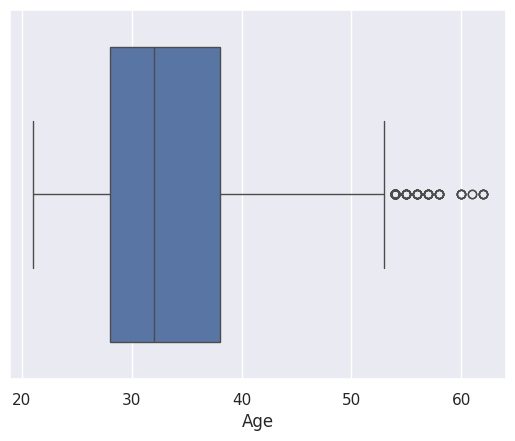

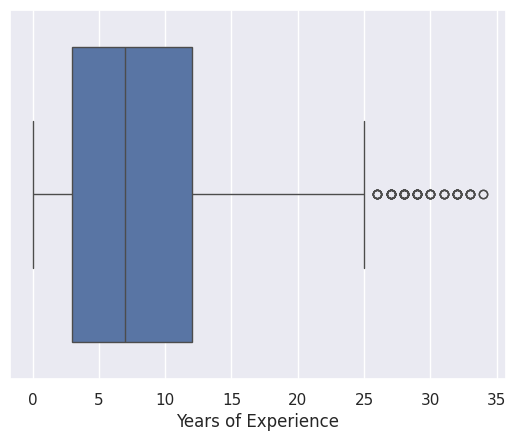

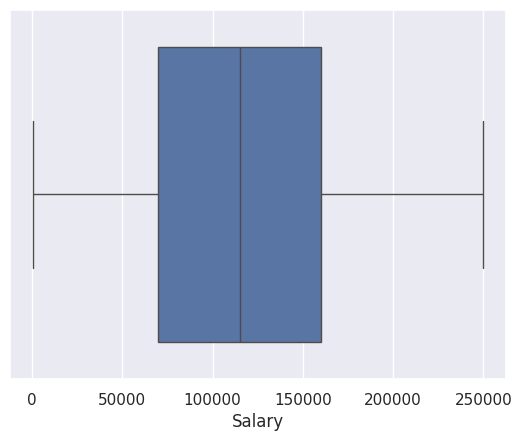

In [62]:
for i in data.columns:
    if data[i].dtypes!=object:
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [63]:
q1=data.quantile(0.25, numeric_only=True)
q3=data.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

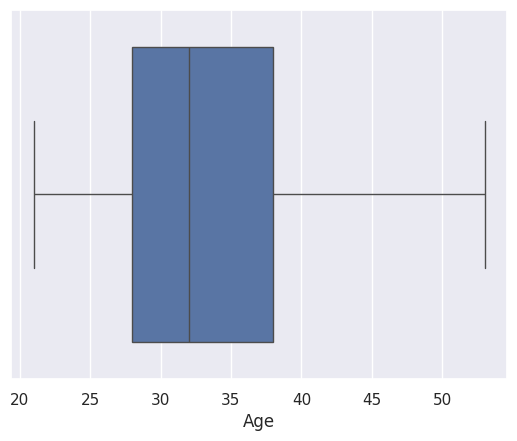

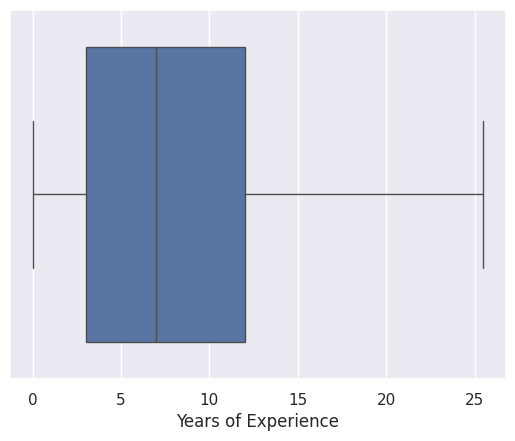

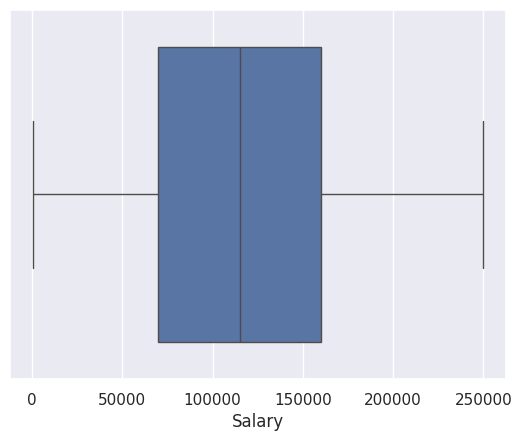

In [64]:
for i in data.columns:
    if pd.api.types.is_numeric_dtype(data[i]):
        data[i] = np.where(data[i] > Upper[i],Upper[i],data[i])
        data[i] = np.where(data[i] < Lower[i],Lower[i],data[i])
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [65]:
data = pd.get_dummies(data, drop_first=True, dtype = int)

data

,Age,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_High School,Education Level_Master's Degree,Education Level_PhD,Seniority_Junior,Seniority_Lead/Principal,Seniority_Mid-Level,Seniority_Senior
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,1,0
1,28.0,3.0,65000.0,0,0,0,1,0,0,0,1,0
2,45.0,15.0,150000.0,1,0,0,0,1,0,1,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,0,1
4,52.0,20.0,200000.0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6699,49.0,20.0,200000.0,0,0,0,0,1,0,0,0,0
6700,32.0,3.0,50000.0,1,0,1,0,0,0,0,1,0
6701,30.0,4.0,55000.0,0,0,0,0,0,0,0,1,0
6702,46.0,14.0,140000.0,1,0,0,1,0,0,1,0,0


In [66]:
targets = data['Salary']

inputs = data.drop(['Salary'],axis=1)

In [68]:
scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,Age,Years of Experience,Gender_Male,Gender_Other,Education Level_High School,Education Level_Master's Degree,Education Level_PhD,Seniority_Junior,Seniority_Lead/Principal,Seniority_Mid-Level,Seniority_Senior
0,-0.210796,-0.515806,0.908059,-0.045766,-0.267731,-0.620045,-0.506849,-0.486759,-0.468370,1.843339,-0.603222
1,-0.745054,-0.853723,-1.101250,-0.045766,-0.267731,1.612785,-0.506849,-0.486759,-0.468370,1.843339,-0.603222
2,1.525543,1.173781,0.908059,-0.045766,-0.267731,-0.620045,1.972973,-0.486759,2.135066,-0.542494,-0.603222
3,0.323462,-0.177888,-1.101250,-0.045766,-0.267731,-0.620045,-0.506849,-0.486759,-0.468370,-0.542494,1.657764
4,2.460494,2.018575,0.908059,-0.045766,-0.267731,1.612785,-0.506849,-0.486759,-0.468370,-0.542494,-0.603222
...,...,...,...,...,...,...,...,...,...,...,...
6693,2.059801,2.018575,-1.101250,-0.045766,-0.267731,-0.620045,1.972973,-0.486759,-0.468370,-0.542494,-0.603222
6694,-0.210796,-0.853723,0.908059,-0.045766,3.735089,-0.620045,-0.506849,-0.486759,-0.468370,1.843339,-0.603222
6695,-0.477925,-0.684764,-1.101250,-0.045766,-0.267731,-0.620045,-0.506849,-0.486759,-0.468370,1.843339,-0.603222
6696,1.659107,1.004822,0.908059,-0.045766,-0.267731,1.612785,-0.506849,-0.486759,2.135066,-0.542494,-0.603222


In [70]:
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

In [72]:
def create_model(trial):
    # Building artificial neural network
    model = Sequential()

     # we add 2 hidden layers and 1 output layer
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='relu'))

    # Suggest hyperparameters for the optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='MAE', metrics=['MAE'])

    return model

In [78]:
def optimal(trial):

    # Suggest the number of epochs and batch size
    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    return r2

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=10)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-04-18 10:38:39,949] A new study created in memory with name: no-name-2ef8c3cc-fb5d-4288-8394-5a64a47e4815


Epoch 1/37


/tmp/ipykernel_2237/32313782.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115485.2422 - loss: 115485.2422
Epoch 2/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.2188 - loss: 115485.2188
Epoch 3/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.1953 - loss: 115485.1953
Epoch 4/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.1562 - loss: 115485.1562
Epoch 5/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.0859 - loss: 115485.0859
Epoch 6/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.0938 - loss: 115485.0938
Epoch 7/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115485.0391 - loss: 115485.0391
Epoch 8/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115484.9453 - loss: 115484.9453
Epoch 9/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 115484.9062 - loss: 115484.9062
Epoch 10/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115484.8672 - loss: 115484.8672
Epoch 11/37
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 115484.7891 - loss: 115484.7891
Epoch 12

[I 2026-04-18 10:38:53,180] Trial 0 finished with value: -4.614008824666178 and parameters: {'epochs': 37, 'batch_size': 44, 'units_layer1': 17, 'units_layer2': 27, 'optimizer': 'rmsprop', 'learning_rate': 1.603407382297408e-05}. Best is trial 0 with value: -4.614008824666178.


...

Epoch 1/28


/tmp/ipykernel_2237/32313782.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - MAE: 115484.8203 - loss: 115484.8203
Epoch 2/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MAE: 115484.3125 - loss: 115484.3125
Epoch 3/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115483.7578 - loss: 115483.7578
Epoch 4/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115483.0547 - loss: 115483.0547
Epoch 5/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115482.2031 - loss: 115482.2031
Epoch 6/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115481.1797 - loss: 115481.1797
Epoch 7/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115479.8672 - loss: 115479.8672
Epoch 8/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115478.3359 - loss: 115478.3359
Epoch 9/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115476.5781 - loss: 115476.5781
Epoch 10/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115474.4219 - loss: 115474.4219
Epoch 11/28
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115472.0078 - loss: 115472.0078
Epoch 12

[I 2026-04-18 10:41:14,959] Trial 9 finished with value: -4.603864855374437 and parameters: {'epochs': 28, 'batch_size': 18, 'units_layer1': 12, 'units_layer2': 30, 'optimizer': 'rmsprop', 'learning_rate': 7.108700684755325e-05}. Best is trial 1 with value: 0.8004425022858398.


Best trial: 0.8004425022858398
Best hyperparameters: {'epochs': 26, 'batch_size': 44, 'units_layer1': 26, 'units_layer2': 18, 'optimizer': 'sgd', 'learning_rate': 0.0010666034617775523}


In [79]:
best_params = study.best_trial.params

best_params

{'epochs': 26,
 'batch_size': 44,
 'units_layer1': 26,
 'units_layer2': 18,
 'optimizer': 'sgd',
 'learning_rate': 0.0010666034617775523}

In [80]:
# Train the final model with the best hyperparameters

best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='relu'))

In [81]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])


In [82]:
best_model.compile(optimizer=best_optimizer, loss='MAE', metrics=['mae'])

In [83]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])

    '''Predictions and probabilities for the training set'''

    y_train_prob = model.predict(X_train)

    '''Predictions and probabilities for the test set'''

    y_test_prob = model.predict(X_test)

    '''Calculate metrics for the training set'''

    r2_train = r2_score(y_train, y_train_prob)


    '''Calculate metrics for the test set'''

    r2_test = r2_score(y_test, y_test_prob)


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'R2': [r2_train * 100, r2_test * 100],

    })

    return results

In [84]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 115485.2734 - mae: 115485.2734
Epoch 2/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 115485.1562 - mae: 115485.1562
Epoch 3/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 115484.7500 - mae: 115484.7500
Epoch 4/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 115484.2266 - mae: 115484.2266
Epoch 5/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 115483.4219 - mae: 115483.4219
Epoch 6/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 115482.1719 - mae: 115482.1719
Epoch 7/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115479.8203 - mae: 115479.8203
Epoch 8/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115474.7891 - mae: 115474.7891
Epoch 9/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115460.9688 - mae: 115460.9688
Epoch 10/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 115401.8984 - mae: 115401.8984
Epoch 11/26
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 114409.2656 - mae: 114409.26

,Dataset,R2
0,Train,76.802542
1,Test,78.475753
